# 01 · El problema y los datos



#### ***(Hola, Valero. Como siempre, a lo largo de todo el proyecto te dejo una serie de paréntesis como este para explicar, con mis propias palabras y de manera informal, los desafíos, el razonamiento y las decisiones tomadas durante su elaboración. Un saludo!)***




## Qué pide el enunciado

El taller pide cuatro cosas:

1. **Definir un problema financiero** con una entrada `X`, una salida `Y` y un modelo que aprenda `Y = f(X)`.
2. **Generar datos sintéticos** con tres modelos generativos de los vistos en clase, más un cuarto modelo simple (por ejemplo, añadir ruido a los datos reales).
3. **Entrenar el modelo downstream** con distintas proporciones de datos reales y sintéticos y **analizar el impacto**.
4. Reportar **curvas de loss** de todos los entrenamientos y las gráficas de resultados.

La pregunta central de la clase, la que hay que responder con números, es la que el profesor formuló al principio:
**¿pueden los modelos generativos mejorar el rendimiento de un modelo de machine learning aumentando los datos de entrenamiento?**

## Por qué la elección del problema es la decisión más importante

#### ***(Un detalle fácil de pasar por alto y que fue fundamental a la hora de elegir el problema fue un detalle que mencionaste en clase, y es que si el problema downstream tiene datos de sobra, los datos sintéticos no pueden aportar nada y el trabajo entero acaba midiendo ruido. Dijiste algo asi como que los datos sintéticos ayudan cuando los datos reales son escasos y para los problemas desbalanceados, donde es mejor generar datos solo de la clase minoritaria.)***

Así que buscamos un problema que cumpla tres condiciones a la vez:

- que la clase de interés sea **genuinamente escasa**, para que haya algo que ganar;
- que sea **financieramente relevante**, no un juguete;
- y que tenga **señal real fuera de muestra**, porque si no la tiene no habrá efecto que medir.

#### ***(La tercera condición es la que nos obligó a cambiar de idea a mitad del proyecto, y lo documentamos a continuación.)***

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

## Los datos

Universo y fuente idénticos a los notebooks de Valero: los tickers del S&P 500 de su repositorio, descargados con
`yfinance` y quedándonos con los que tienen histórico completo. De 500 tickers sobreviven **23**, con datos diarios
desde 1962. Es una muestra pequeña en activos pero muy larga en tiempo, que es exactamente lo que necesitamos para
tener varias crisis independientes.

Trabajamos con **retornos logarítmicos**, `log(P_t) - log(P_{t-1})`, por las razones de siempre: son aditivos en el
tiempo, aproximadamente estacionarios y comparables entre activos con precios muy distintos.

In [2]:
from src import config, data

prices = data.load_prices()
returns = data.log_returns(prices)

print(f"Activos supervivientes: {prices.shape[1]}")
print(f"Retornos diarios:       {len(returns)}")
print(f"Periodo:                {returns.index.min().date()} -> {returns.index.max().date()}")
print(f"Tickers: {', '.join(prices.columns)}")

Activos supervivientes: 23
Retornos diarios:       16274
Periodo:                1962-01-03 -> 2026-09-01
Tickers: AEP, BA, CAT, CNP, CVX, DIS, DTE, ED, GD, GE, HON, HPQ, IBM, IP, JNJ, KO, KR, MMM, MO, MRK, MSI, PG, XOM


## Definición del problema

- **Entrada `X`**: los **60 días** hábiles previos de retornos logarítmicos de los 23 activos. Una ventana es
  por tanto una matriz `60 x 23`. Usamos el mismo tamaño de ventana que el profesor.
- **Salida `Y`**: una etiqueta binaria que responde a *"¿los próximos 20 días hábiles serán un régimen de alta
  volatilidad?"*. Concretamente, si la **volatilidad realizada anualizada de la cartera equiponderada en los
  próximos 20 días** supera el **percentil 95 del bloque de entrenamiento**.
- **Modelo**: una CNN 1D de clasificación, con arquitectura fija (notebook 02).

### Por qué la volatilidad futura y no la caída futura

#### ***(Esta fue la primera parte del trabajo que nos dio problemas. En la primera iteración, nuestro proyecto consistía en intentar predecir si habría una caída de al menos el 8 % en los próximos 20 días. La verdad es que es bastante intuitivo.)***

#### ***(En esencia, medimos si el modelo predictivo presenta alguna señal y comprobamos que, fuera de muestra, no tiene ninguna. La tabla lo muestra utilizando los dos predictores financieros clásicos.)***

Esto no es un fallo de implementación, es exactamente lo que predice la **eficiencia débil del mercado**: los
retornos futuros no se pueden anticipar a partir de retornos pasados. La **volatilidad**, en cambio, sí es fuertemente
persistente (efectos ARCH, agrupamiento de volatilidad), y por eso la pregunta sobre el régimen de volatilidad sí
tiene respuesta.

#### ***(Si bien la pregunta no resulta tan vistosa a primera vista, un cambio de régimen en la volatilidad es una formulación estándar en gestión de riesgos: es lo que alimenta el VaR, el dimensionamiento de posiciones y las llamadas de margen. Así que ganamos, al mismo tiempo, en relevancia y en capacidad predictiva.)***

`lift` es la métrica que hay que leer: es el PR-AUC dividido por la tasa base. Un modelo aleatorio tiene lift 1.

In [3]:
from src import experiments

tabla_neg = experiments.drawdown_negative_result()
display(tabla_neg.round(3))
print()
print("Lectura: con el target de caída, el lift en test es ~1, es decir indistinguible del azar.")
print("Con el target de volatilidad, los mismos predictores alcanzan lift ~6.")

,tasa_base_test,test_pr_auc,lift,test_roc_auc
Régimen de volatilidad / vol. realizada,0.078,0.453,5.811,0.756
Régimen de volatilidad / drawdown actual,0.078,0.492,6.320,0.754
Caída >= 8% / vol. realizada,0.052,0.069,1.335,0.566
Caída >= 8% / drawdown actual,0.052,0.096,1.854,0.610



Lectura: con el target de caída, el lift en test es ~1, es decir indistinguible del azar.
Con el target de volatilidad, los mismos predictores alcanzan lift ~6.


## Construcción de las ventanas y partición temporal

Dos decisiones metodológicas que separan un trabajo correcto de uno con resultados inflados.

### 1. La ventana de features y la de target no se solapan

La ventana `k` usa los retornos `[i-60, i)` como entrada y mira `[i, i+20)` para la etiqueta. El modelo nunca ve
ni un solo día del periodo que tiene que predecir.

### 2. Partición cronológica con embargo, no aleatoria

#### ***(Me di cuenta de que tus notebooks usan train_test_split(..., random_state=42). Y decidimos apartarnos de eso deliberadamente porque segun he estado mirando, es habitual en machine learning aplicado a series temporales que por ejemplo, en las ventanas consecutivas que comparten 59 de sus 60 días. Con una partición aleatoria, la ventana del día t acaba en train y la del día t+1 en test, así que el modelo se evalúa sobre datos que prácticamente ha visto. El resultado se infla un poco de manera anrtifical, no?)***


Nuestra partición es **cronológica 70/15/15** y además descarta **80 ventanas (60 + 20) en cada frontera**. Ese
*embargo* es necesario porque cada etiqueta mira 20 días hacia el futuro: sin él, las últimas etiquetas de train
estarían determinadas por días que pertenecen ya al periodo de validación.

### 3. El umbral del target se estima solo en train

El percentil 95 es un estadístico de los datos. Calcularlo sobre la muestra completa dejaría que el periodo de test
influyera en sus propias etiquetas. Por eso el etiquetado ocurre **después** de partir, no antes.

In [4]:
split, returns, extras = data.load_problem()

print(f"Target: {split.target}   umbral = {split.threshold:.4f} (volatilidad anualizada)")
print(f"Embargo: {split.embargo} ventanas descartadas en cada frontera\n")
display(split.summary())

Target: vol   umbral = 0.2342 (volatilidad anualizada)
Embargo: 80 ventanas descartadas en cada frontera



,bloque,n_ventanas,desde,hasta,n_positivos,tasa_positivos,rachas,episodios_independientes
0,train,11336,1962-03-28,2007-04-11,567,0.0500,38,14
1,val,2350,2007-08-06,2016-12-01,312,0.1328,11,4
2,test,2349,2017-03-30,2026-08-04,183,0.0779,11,5


## La escasez real de la clase minoritaria

Aquí está el argumento que justifica todo el proyecto, y no es el número de positivos.

En train hay **567 ventanas de estrés**, que suena a suficiente. Pero esas ventanas no son independientes: se
solapan casi por completo y vienen agrupadas en **un puñado de episodios de mercado**. Contando episodios separados
por al menos seis meses, el bloque de entrenamiento contiene del orden de **14 episodios** en 45 años, y el de test
apenas **5**.

#### ***(Aquí fue cuando de verdad entendí eso que comentabas en clase: en finanzas tenemos pocos datos. El tamaño muestral efectivo de la clase rara es minúsculo, de apenas unas pocas decenas de observaciones, no de varios cientos. Y es precisamente aquí donde nos dijiste que los datos sintéticos tienen algo que aportar.)***

La gráfica lo muestra mejor que cualquier tabla: los positivos no están repartidos, son bloques.

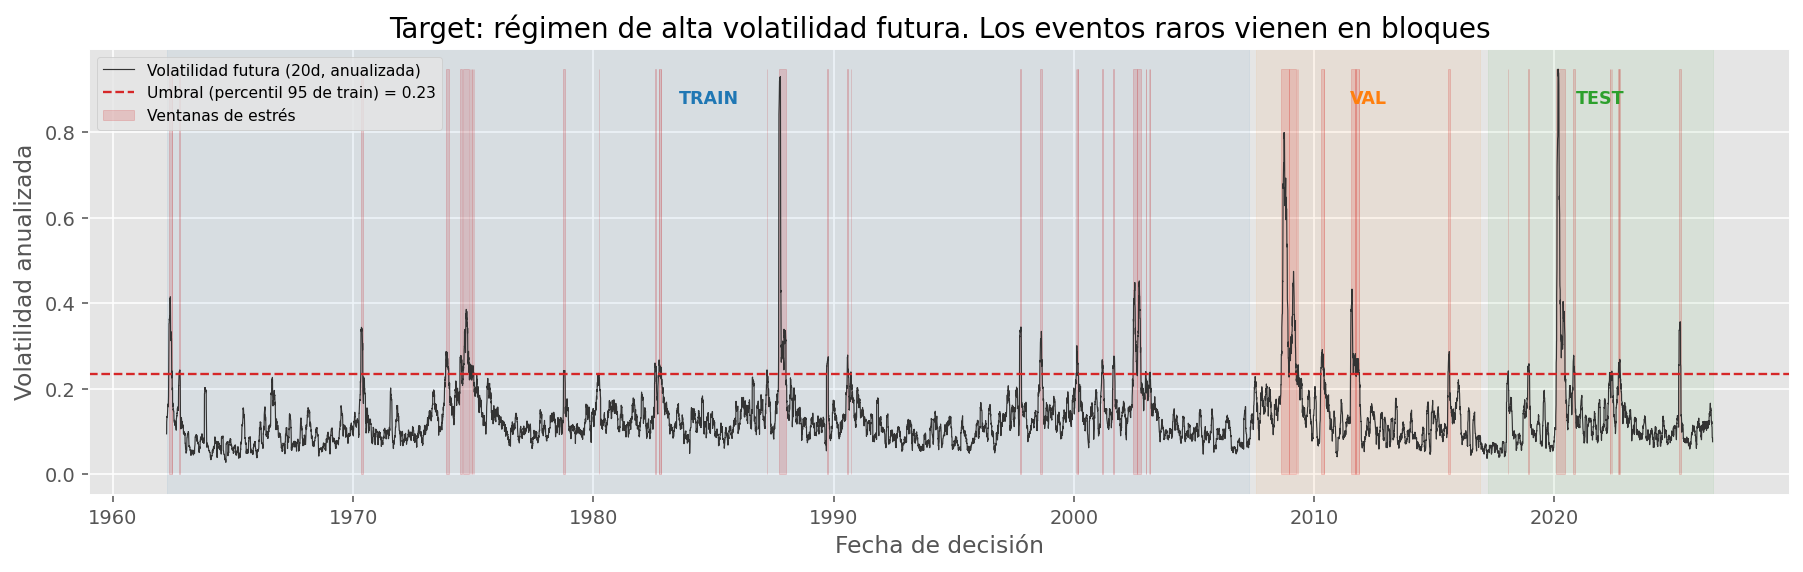

train:  567 ventanas positivas  ->  14 episodios independientes
val  :  312 ventanas positivas  ->   4 episodios independientes
test :  183 ventanas positivas  ->   5 episodios independientes


In [5]:
from src import plots

fig = plots.plot_target_timeline(
    extras["dates"], extras["target_value"], extras["y"],
    extras["threshold"], extras["slices"],
)
display(Image(str(fig)))

for nombre, y in (("train", split.y_train), ("val", split.y_val), ("test", split.y_test)):
    print(f"{nombre:5s}: {int(y.sum()):4d} ventanas positivas  ->  "
          f"{data.count_episodes(y, min_gap=126):2d} episodios independientes")


#### ***(Los positivos no están repartidos a lo largo de todo el histórico, sino que aparecen agrupados en *clusters*. Esto significa que muchas ventanas positivas son, en realidad, casi la misma crisis observada con apenas un día de diferencia. Por tanto, el tamaño efectivo de la muestra es mucho menor, y por eso esta partición nos parecía especialmente importante.)***
```


## Un hallazgo que nos hizo cambiar el plan: el PCA no sirve aquí

El plan inicial era reducir con PCA las ventanas aplanadas (`60 x 23 = 1380` dimensiones) al 90% de varianza,
esperando la regla de Valero de que bastaría con un ~10% de las dimensiones. El motivo era práctico: con solo
~570 ventanas de estrés, la matriz de covarianza en 1380 dimensiones es **singular** y no se puede muestrear de ella.

Lo medimos en lugar de suponerlo, y el resultado fue **986 de 1380 componentes**. La curva de varianza explicada es
casi una línea recta, igual que la de un ruido blanco: 60 componentes capturan el 31%, 400 capturan el 61%.

**Los retornos diarios no tienen estructura lineal de baja dimensión que explotar.** Y truncar el PCA es peor que
inútil aquí: elimina varianza, así que las ventanas reconstruidas salen sistemáticamente *más tranquilas* que las
reales. Para un modelo cuyo trabajo es reconocer turbulencia, ese sesgo es exactamente el contrario del que
queremos.

**Decisión:** los generadores trabajan en el **espacio nativo estandarizado** (1380 dimensiones, sin pérdida de
información), y el problema de la covarianza singular se resuelve donde le corresponde, dentro del generador
gaussiano, con **shrinkage de Ledoit-Wolf**, que es el estimador diseñado para el régimen `n < p` y práctica
estándar en construcción de carteras. El PCA se conserva en el código para la ablación documentada y para el bonus
cuántico, donde un espacio pequeño es lo único que hace simulable el circuito.

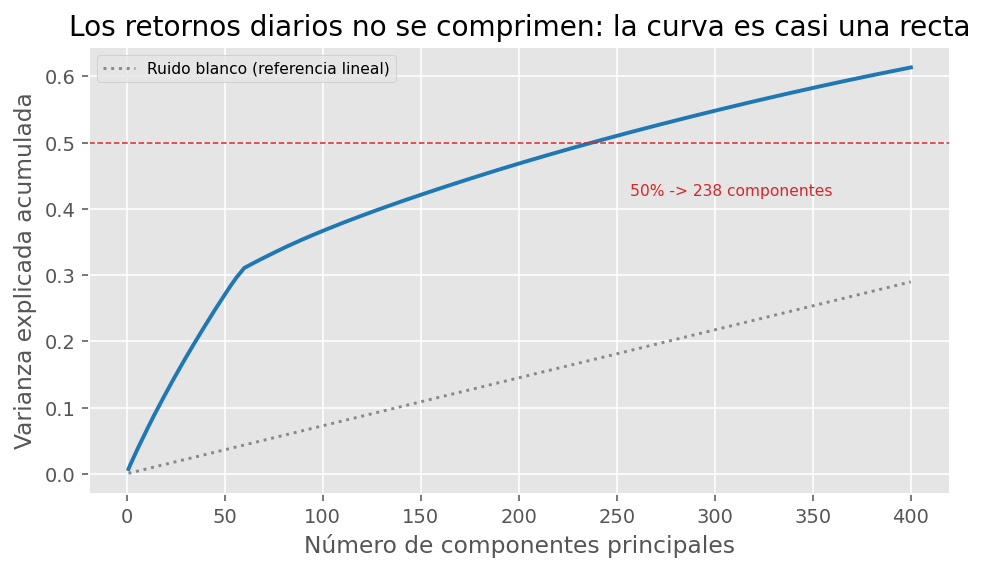

  60 componentes -> 31.1% de varianza explicada
 128 componentes -> 39.9% de varianza explicada
 200 componentes -> 46.8% de varianza explicada
 400 componentes -> 61.4% de varianza explicada


In [6]:
from src import representation as rp

curva = rp.variance_curve(split.X_train, max_components=400)
fig = plots.plot_variance_curve(curva)
display(Image(str(fig)))

for k in (60, 128, 200, 400):
    print(f"{k:4d} componentes -> {curva[k-1]:.1%} de varianza explicada")

## Resumen del notebook

| Decisión | Qué elegimos | Por qué |
|---|---|---|
| Entrada | 60 días × 23 activos de log-retornos | Igual que el profesor; retornos aditivos y estacionarios |
| Target | Volatilidad futura a 20 días > percentil 95 de train | Evento raro (5%), relevante en riesgo y **con señal real** |
| Target descartado | Caída ≥ 8% a 20 días | Lift ≈ 1 en test: eficiencia débil del mercado |
| Partición | Cronológica 70/15/15 + embargo de 80 ventanas | Las ventanas solapan; una partición aleatoria mide memoria |
| Umbral del target | Percentil 95 **solo de train** | Evitar que test influya en sus propias etiquetas |
| Espacio generativo | Nativo estandarizado (1380 dims) | El PCA necesita 986 componentes: no hay nada que comprimir |
| Covarianza singular | Shrinkage de Ledoit-Wolf | Estimador correcto para `n < p`, sin perder información |


#### ***(Con esto terminamos la descarga de datos y la definición de las particiones. Me pareció especialmente curioso lo del PCA y que su capacidad de compresión fuese tan limitada para este caso)***

